In [1]:
import pandas as pd
import numpy as np

DATA DESCRIPTION
```
file name -> Columns
quater-i.csv -> ['order_id', 'quantity', 'item_id', 'choice_description_id' 'item_price']
items.csv -> ['item_id', 'item_name']
```
Dataset Link - https://drive.google.com/drive/folders/1Z0kaFybvgFeczeUj4dldUnhTdloLqLsL?usp=share_link

In [2]:
# import like this
# items_path = "https://drive.google.com/file/d/1MokLL6WAVRrA4TcWSCocTG_U7H-iN4Nw/view?usp=drive_link"
# q1_path = "/content/drive/MyDrive/DSMP/01 - Python/Daily Tasks/Week 7/data/quarter-1.csv"
# q2_path = "/content/drive/MyDrive/DSMP/01 - Python/Daily Tasks/Week 7/data/quarter-2.csv"
# q3_path = "/content/drive/MyDrive/DSMP/01 - Python/Daily Tasks/Week 7/data/quarter-3.csv"

items = pd.read_csv('Dataset\items.csv')
q1= pd.read_csv('Dataset\quarter-1.csv')
q2 = pd.read_csv('Dataset\quarter-2.csv')
q3 = pd.read_csv('Dataset\quarter-3.csv')
q1

,order_id,quantity,item_id,choice_description_id,item_price
0,1,1,1,1,$3.39
1,1,1,2,2,$3.39
2,2,2,4,3,$16.98
3,4,1,7,6,$9.25
4,6,1,9,8,$8.75
...,...,...,...,...,...
2270,1831,1,16,0,$1.50
2271,1833,1,6,276,$11.75
2272,1833,1,6,904,$11.75
2273,1834,1,20,303,$8.75


###`Q:1-5`
1. You are given three quater files, your job is to append these three files and make a single dataframe.
2. Have a index as Q-1 Q-2 Q-3 for respective quater files in the dataframe
3. Your are given a file items.csv which has item_id and item_name. Find out most sold items in each quarter.
4. Find out items which has made most revenue in each quarter.
5. Find out avg order price of each quarter.

***Note: item_price is given as str with $ sign, in earlier task you have converted this to rupees, here too first convert item_price field in rupees.***

In [3]:
#1 Merge Quarter File
quarter = pd.concat([q1,q2,q3],ignore_index = True)
quarter

,order_id,quantity,item_id,choice_description_id,item_price
0,1,1,1,1,$3.39
1,1,1,2,2,$3.39
2,2,2,4,3,$16.98
3,4,1,7,6,$9.25
4,6,1,9,8,$8.75
...,...,...,...,...,...
4617,1829,1,23,92,$11.25
4618,1830,1,23,1043,$11.25
4619,1832,1,10,116,$8.75
4620,1832,1,8,0,$4.45


In [4]:
#2
quarter = pd.concat([q1,q2,q3],keys=['q1','q2','q3'])
quarter = quarter.reset_index()
quarter.head()

,level_0,level_1,order_id,quantity,item_id,choice_description_id,item_price
0,q1,0,1,1,1,1,$3.39
1,q1,1,1,1,2,2,$3.39
2,q1,2,2,2,4,3,$16.98
3,q1,3,4,1,7,6,$9.25
4,q1,4,6,1,9,8,$8.75


In [5]:
#3
quarter_item = quarter.merge(items,how = 'left',on = 'item_id')
quarter_item

,level_0,level_1,order_id,quantity,item_id,choice_description_id,item_price,item_name
0,q1,0,1,1,1,1,$3.39,Izze
1,q1,1,1,1,2,2,$3.39,Nantucket Nectar
2,q1,2,2,2,4,3,$16.98,Chicken Bowl
3,q1,3,4,1,7,6,$9.25,Steak Soft Tacos
4,q1,4,6,1,9,8,$8.75,Chicken Crispy Tacos
...,...,...,...,...,...,...,...,...
4617,q2,2342,1829,1,23,92,$11.25,Veggie Burrito
4618,q2,2343,1830,1,23,1043,$11.25,Veggie Burrito
4619,q2,2344,1832,1,10,116,$8.75,Chicken Soft Tacos
4620,q2,2345,1832,1,8,0,$4.45,Chips and Guacamole


In [6]:
quarter_item.groupby(['level_0','item_name'])['quantity'].sum().sort_values(ascending = False).reset_index().groupby('level_0').first()

,item_name,quantity
level_0,,
q1,Chicken Bowl,367
q2,Chicken Bowl,394


In [7]:
#4
quarter_item['item_price'] = quarter_item['item_price'].apply(lambda x : float(x.replace('$','').strip()))
quarter_item['total_item_price'] = quarter_item['quantity']*quarter_item['item_price']

In [8]:

quarter_item.groupby(['level_0','item_name'])['total_item_price'].sum().sort_values(ascending = False).reset_index().groupby('level_0').first()

,item_name,total_item_price
level_0,,
q1,Chicken Bowl,3852.38
q2,Chicken Bowl,4192.25


In [9]:
#5 Average Price
quarter_item.groupby(['level_0','order_id'])['total_item_price'].sum().sort_values(ascending = False).reset_index().groupby('level_0')['total_item_price'].mean()


level_0
q1    13.809488
q2    13.279828
Name: total_item_price, dtype: object

###`Q-6` From the IPL wala dataset you have to find the Purple cap holder each season.

*Note: Bowler with most no wickets in a season gets purple cap. If more than one bowler have same no of wickets in the season, one with least ecomnomy among them is purple cap holder.*

Bowler's Economy = runs-conceded per six balls

In [26]:
ipl_df1 = pd.read_csv('Dataset\ipl_deliveries.csv')
ipl_df2 = pd.read_csv('Dataset\ipl-matches.csv')

df = ipl_df1.merge(ipl_df2[['Season','ID']],how='inner',on ='ID')
df['extra_type'].unique()

array([nan, 'legbyes', 'wides', 'byes', 'noballs', 'penalty'],
      dtype=object)

In [27]:
df

,ID,Team,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam,BowlingTeam,Season
0,1312200,Rajasthan RoyalsGujarat Titans,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans,2022
1,1312200,Rajasthan RoyalsGujarat Titans,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans,2022
2,1312200,Rajasthan RoyalsGujarat Titans,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans,2022
3,1312200,Rajasthan RoyalsGujarat Titans,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans,2022
4,1312200,Rajasthan RoyalsGujarat Titans,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225949,335982,Royal Challengers BangaloreKolkata Knight Riders,2,14,5,P Kumar,I Sharma,SB Joshi,legbyes,0,1,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders,2007/08
225950,335982,Royal Challengers BangaloreKolkata Knight Riders,2,14,6,SB Joshi,I Sharma,P Kumar,NaN,1,0,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders,2007/08
225951,335982,Royal Challengers BangaloreKolkata Knight Riders,2,14,7,P Kumar,I Sharma,SB Joshi,NaN,0,0,0,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders,2007/08
225952,335982,Royal Challengers BangaloreKolkata Knight Riders,2,15,1,SB Joshi,LR Shukla,P Kumar,wides,0,1,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders,2007/08


In [12]:
#finding bowler Economy


In [13]:
#total wicket taken by the bowler

df['IsBowlerWicket'] = df['kind'].apply(lambda x : 1 if x in ['caught', 'caught and bowled','bowled', 'stumped', 'lbw', 'hit wicket', 'obstructing the field'] else 0)
df['BowlerRun'] = df['extra_type'].apply(lambda x : 0 if x in ['legbyes','byes'] else 1) * df['total_run']
df['Isvaliedball'] = df['extra_type'].apply(lambda x : 0 if x in ['wides','noballs'] else 1)
pcap_df = df.groupby(['Season','bowler'],as_index = False)[['IsBowlerWicket','BowlerRun','Isvaliedball']].sum()
pcap_df['Economy'] = pcap_df['BowlerRun']/pcap_df['Isvaliedball']*6
pcap_df.sort_values(by = ['IsBowlerWicket','Economy'],ascending = [False,True],inplace = True)
pcap_df.groupby('Season').first()

,bowler,IsBowlerWicket,BowlerRun,Isvaliedball,Economy
Season,,,,,
2007/08,Sohail Tanvir,22,266,247,6.461538
2009,RP Singh,23,417,358,6.988827
2009/10,PP Ojha,21,429,353,7.291785
2011,SL Malinga,28,375,378,5.952381
2012,M Morkel,25,453,378,7.190476
2013,DJ Bravo,32,497,375,7.952000
2014,MM Sharma,23,452,323,8.396285
2015,DJ Bravo,26,426,314,8.140127
2016,B Kumar,23,490,396,7.424242


###`Q-7:` Best bowler in death overs.
*Note: Have taken most no of wickets in case of tie with least economy*

Death Overs - [16-20]

In [14]:
temp_df = df[df['overs']>=15]

mask1 = temp_df['kind'].apply( lambda x : x not in ['retired hurt', 'retired out', 'obstructing the field','run out'])
mask2 = temp_df['isWicketDelivery'] == 1
       
death_wicket = temp_df[mask1 & mask2]
death_wicket = death_wicket.groupby(['bowler'])['isWicketDelivery'].sum()
death_wicket.sort_values(ascending = False)
# death_wicket.reset_index().sort_values(by = 'isWicketDelivery',ascending = False).groupby(['Season']).first()

bowler
DJ Bravo           115
SL Malinga         108
B Kumar             90
JJ Bumrah           80
SP Narine           67
                  ... 
T Shamsi             1
Shoaib Malik         1
Y Venugopal Rao      1
A Flintoff           1
A Choudhary          1
Name: isWicketDelivery, Length: 317, dtype: int64

###`Q-8` Batsman record season wise

Make a function which takes a input `batsman_name` and it returns a dataframe.
Columns of the data frame are - `['Season','Innings', 'TotalRuns', 'Avg', 'HighestScore','StrikeRate']`.
* In result make `Season` column as index.

* Avg - total_runs/ no of time got out. - player_out column will help.
* StrikeRate -(total_runs/ balls faced) * 100- wides are not included in batsman ball faced counts. No balls are included. -> Extra_type column will help
* Batsman Can score runs on No Balls.
* Batsman can get out on No Ball or Wides. And even while being on non-striker. Keep these things in mind before masking.

In [ ]:
# out_df = pd.DataFrame(columns=['Season','Innings', 'TotalRuns', 'Avg', 'HighestScore','StrikeRate'] )

def batsman_record(bat):
    out_df = pd.DataFrame(columns=['Season'] )
    temp_df = df[(df['isWicketDelivery'] == False) & (df['batter'] == bat)]
    temp_df1 = temp_df.groupby(['Season'])
    temp_df2 = temp_df.groupby(['Season','ID'])
    
    out_df['Season'] = temp_df['Season'].unique()[::-1]
    out_df = out_df.merge(temp_df1['ID'].nunique(),how='inner',on='Season')    
    
    out_df = out_df.merge(temp_df1['batsman_run'].sum(),how='inner',on='Season')    
    
    out_df['Avg'] = round(out_df['batsman_run']/out_df['ID'],2)
    
    highest_score = temp_df2['batsman_run'].sum().reset_index().sort_values(by = 'batsman_run',ascending = False).groupby('Season').first()
    out_df = out_df.merge(highest_score,how='inner',on='Season')    
    
    out_df.rename(columns = {'ID_x':'Innings','batsman_run_x' : 'TotalRuns','ID_y':'Match_no','batsman_run_y':'HighestScore'},inplace = True)
    
    temp_df3 = df[(df['extra_type'] != 'wides')&(df['batter'] == bat)].groupby('Season')
    bowl_faced = temp_df3['innings'].count()
    out_df = out_df.merge(bowl_faced,how='inner',on='Season')    
    out_df.rename(columns = {'innings':'Bowl_faced'},inplace = True)
    out_df['StrikeRate'] = 100*out_df['TotalRuns']/out_df['Bowl_faced']
    return out_df


record = batsman_record('V Kohli').set_index('Season')
record[['Season','Innings', 'TotalRuns', 'Avg', 'HighestScore','StrikeRate']]

In [ ]:
batter_df = df.copy()
batter_df['isBatsmanBall'] = batter_df['extra_type'].apply(lambda x : 1 if x != "wides" else 0)


In [41]:
def batsman_record(batsman):
    bdf = batter_df[batter_df['batter'] == batsman].copy()
    bdf['isBatsmanOut'] = bdf['batter'] == bdf['player_out']
    bdf = bdf.groupby(['Season','ID'],as_index = False)
    df = bdf[["batsman_run","isBatsmanBall","isBatsmanOut"]].sum()
    innings = df.groupby("Season")['ID'].count()
    df = df.groupby('Season').agg({
        
        "batsman_run":["sum","max"],
        "isBatsmanBall":"sum",
        "isBatsmanOut":"sum"        
    })
    
    df["innings"] = innings
    df["TotalRuns"] = df[("batsman_run","sum")]
    df["Avg"] = df['TotalRuns']/df[('isBatsmanOut', 'sum')]
    df["HighestScore"] = df[('batsman_run', 'max')]
    df["StrikeRate"] = (df['TotalRuns']*100)/df[('isBatsmanBall', 'sum')]
    return df.drop(["batsman_run","isBatsmanBall","isBatsmanOut"],axis=1)

batsman_record('MS Dhoni')

,innings,TotalRuns,Avg,HighestScore,StrikeRate
,,,,,
Season,,,,,
2007/08,14,414,41.400000,65,133.548387
2009,13,332,41.500000,58,127.203065
2009/10,11,287,31.888889,66,136.666667
2011,13,392,43.555556,70,158.704453
2012,17,358,32.545455,51,128.776978
2013,16,461,46.100000,67,162.897527
2014,15,371,74.200000,57,148.400000
2015,17,372,31.000000,53,121.967213


###`Q-9` Using both dataset, make a dataframe as described below

Data Frame columns-> `['PlayerOfThematch', 'BattingFigure', 'BowlingFigure']`

* BattingFigure->`<runs>/<balls>`
* BowlingFigure->`<wicket>/<runs-conceded>`

DataFrame should have one record for each match.

Say 'V Kohli' got POM award then in dataset include his batting figure of that match. Say he scored 112runs in 76 balls. And he hasn't bowled so Bowling Figure will be NaN
```
PlayerOfThematch BattingFigure BowlingFigure
V Kohli          112/76         nan  

```


In [ ]:
#for batter
df = ipl_df1.merge(ipl_df2[['Player_of_Match','ID']],how='inner',on ='ID')
batterdf = df[df['batter'] == df['Player_of_Match']].copy()
batterdf['IsBatsmanBall'] = batterdf['extra_type'].apply(lambda x : 1 if x != 'wides' else 0)
batter = batterdf.groupby(['ID','batter'],as_index = False)[["batsman_run","IsBatsmanBall"]].sum()
batter['BattingFigure'] = batter[['batsman_run',"IsBatsmanBall"]].apply(lambda x : '/'.join(map(str,x.values)),axis = 1)
batter.rename(columns = {"batter":"PlayerofMatch"},inplace = True)
batter.head()

,ID,PlayerofMatch,batsman_run,IsBatsmanBall,BattingFigure
0,335982,BB McCullum,158,73,158/73
1,335983,MEK Hussey,116,54,116/54
2,335985,MV Boucher,39,19,39/19
3,335986,DJ Hussey,38,43,38/43
4,335987,SR Watson,76,49,76/49


In [ ]:
#bowlerdata
bowlerdf = df[df['bowler'] == df['Player_of_Match']].copy()
bowlerdf['IsBowlerWicket'] = bowlerdf['kind'].apply(lambda x : 1 if x in ['caught', 'caught and bowled','bowled', 'stumped', 'lbw', 'hit wicket', 'obstructing the field'] else 0)
df['BowlerRun'] = df['extra_type'].apply(lambda x : 0 if x in ['legbyes','byes'] else 1) * df['total_run']
bowler = bowlerdf.groupby(['ID','bowler'],as_index = False)[["BowlerRun","IsBowlerWicket"]].sum()
bowler['BowlingFigure'] = bowler[['BowlerRun',"IsBowlerWicket"]].apply(lambda x : '/'.join(map(str,x.values)),axis = 1)
bowler.rename(columns = {"bowler":"PlayerofMatch"},inplace = True)
bowler.head()

,ID,PlayerofMatch,BowlerRun,IsBowlerWicket,BowlingFigure
0,335984,MF Maharoof,11,2,11/2
1,335986,DJ Hussey,35,1,35/1
2,335987,SR Watson,39,0,39/0
3,335990,YK Pathan,20,2,20/2
4,335992,SR Watson,20,2,20/2


In [61]:
#Merging two data

data = batter.merge(bowler,on = ['ID','PlayerofMatch'],how='outer').drop(columns = ["batsman_run","IsBatsmanBall","BowlerRun","IsBowlerWicket"])
data[data['PlayerofMatch'] == 'R sharma']

,ID,PlayerofMatch,BattingFigure,BowlingFigure


## **Questions Based on Iris Dataset**

- **Sepal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **SepalLengthCm:** Sepal length of flowers in cm
    - **SepalWidthCm:** Sepal width of flowers in cm

- **Petal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **PetalLengthCm:** Petal length of flowers in cm
    - **PetalWidthCm:** Petal width of flowers in cm

- **Iris Virginica:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Versicolor:** https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Setosa:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv
    - **Unnamed 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

In [63]:
import pandas as pd
sepal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv")
petal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv")

virginica = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv")
versicolor = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv")
setosa = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv")

sepal_all = sepal_all.drop(columns = ['Unnamed: 0'])
petal_all = petal_all.drop(columns = ['Unnamed: 0'])
virginica = virginica.drop(columns = ['Unnamed: 0'])
versicolor = versicolor.drop(columns = ['Unnamed: 0'])
setosa = setosa.drop(columns = ['Unnamed: 0'])


In [ ]:
petal_all


### `Q-10:` Plot a bar chart of the average Sepal Length  of Virginica and average Petal length of Setosa flower.

In [64]:
# flowers_df = sepal_all.merge(virginica,on = 'Id',how = 'left').merge(setosa,on = 'Id',how = 'left').merge(versicolor,on = 'Id',how = 'left')
flowers_df = pd.concat([setosa,versicolor,virginica],ignore_index = False)
flowers_df = flowers_df.merge(sepal_all,how = 'inner',on = 'Id').merge(petal_all,how='inner',on = 'Id')
flowers_df.sample(4)

,Id,Species,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
49,50,Iris-setosa,5.0,3.3,1.4,0.2
149,150,Iris-virginica,5.9,3.0,5.1,1.8
22,23,Iris-setosa,4.6,3.6,1.0,0.2
77,78,Iris-versicolor,6.7,3.0,5.0,1.7


<Axes: xlabel='Species'>

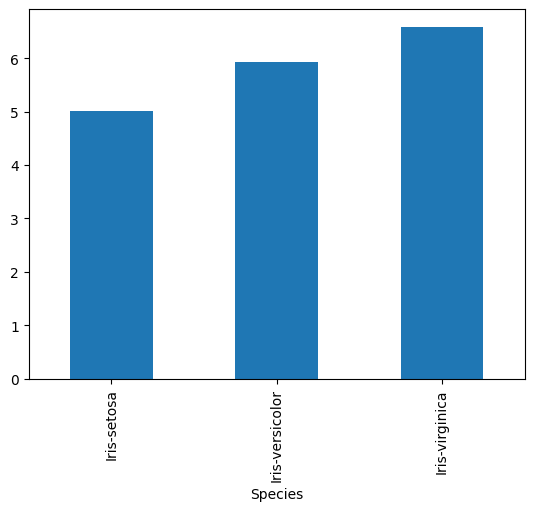

In [65]:
flowers_df.groupby('Species')['SepalLengthCm'].mean().plot(kind = 'bar')
flowers_df.groupby('Species')['PetalLengthCm'].mean().plot(kind = 'bar')

### `Q-11:` Create the complete dataset by uisng the below datasets:
- virginica
- versicolor
- setosa
- sepal all
- petal all

This dataset should have these below column names in order:
1. Id
2. Species
3. SepalLengthCm
4. SepalWidthCm
5. PetalLengthCm
6. PetalWidthCm

Also, the dataset should be shuffled means the `Id` column should not be in increasing or decreasing order. So, make a dataset which has the shuffled Id column. You can use `DataFrame.sample()` method to shuffle.

In [ ]:
flowers_df.set_index('Id')

### `Q-11:` Find out the maximum and minimum sepal width and petal width of Setosa and Versicolor. To do this:
- First create a dataset with merging the required datasets
- After that, use `groupby` to create groups based on the "Species" column.
- Then find out which are asked in this question.


The output should be like this:
```bash
Minimum Sepal width of Setosa is 2.3
Maximum Sepal width of Setosa is 4.4

**************************************************

Minimum Sepal width of Versicolor is 2.0
Maximum Sepal width of Versicolor is 3.4

**************************************************
```

In [ ]:
# flowers_df
data_min = flowers_df.groupby('Species')['SepalLengthCm'].min()
data_max = flowers_df.groupby('Species')['SepalLengthCm'].max()

In [ ]:
print('Minimum Sepal Width of {} is {}'.format(data_min.iloc[0],data_min.index[0]))
print('Maximum Sepal Width of {} is {}'.format(data_max.iloc[0],data_max.index[0]))

print('############################################')

print('Minimum Sepal Width of {} is {}'.format(data_min.iloc[1],data_min.index[1]))
print('Maximum Sepal Width of {} is {}'.format(data_max.iloc[1],data_max.index[1]))

print('############################################')

print('Minimum Sepal Width of {} is {}'.format(data_min.iloc[2],data_min.index[2]))
print('Maximum Sepal Width of {} is {}'.format(data_max.iloc[2],data_max.index[2]))